<a href="https://colab.research.google.com/github/klezyk/MFTI/blob/main/homework_8_gans_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
# Включаем CPU-фоллбэк для операций, не реализованных на MPS (Apple Silicon).
# Должно стоять ДО import torch.
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import random
import zipfile

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import gdown
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from IPython.display import display, Markdown

%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

# Фиксируем сиды для воспроизводимости (random_state=42 по конвенции проекта).
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Устройство вычислений: MPS (Apple Silicon) -> CUDA -> CPU.
device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print('Устройство вычислений:', device)

Устройство вычислений: mps


## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
# --- Загрузка датасета Flickr Faces (подмножество FFHQ) с Google Drive ---
os.makedirs('data', exist_ok=True)

DATA_DIR = 'data'
ARCHIVE_PATH = os.path.join(DATA_DIR, 'faces.zip')
GDRIVE_FILE_ID = '1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x'

# Скачиваем архив только если его ещё нет (guard от повторной загрузки).
if not os.path.exists(ARCHIVE_PATH):
    print('Скачиваем архив с изображениями...')
    gdown.download(id=GDRIVE_FILE_ID, output=ARCHIVE_PATH, quiet=False)
else:
    print('Архив уже скачан:', ARCHIVE_PATH)

# Распаковываем архив. Guard: распаковываем только если в data/ ещё нет
# извлечённых файлов (кроме самого архива).
extracted_already = any(
    name != os.path.basename(ARCHIVE_PATH)
    for name in os.listdir(DATA_DIR)
)
if not extracted_already:
    print('Распаковываем архив...')
    with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zf:
        zf.extractall(DATA_DIR)
    print('Распаковка завершена.')
else:
    print('Архив уже распакован.')

# --- Определяем фактическую структуру распакованных данных ---
# ImageFolder требует структуру root/<класс>/*.jpg. Подбираем корень так,
# чтобы папка с картинками воспринималась как один класс.
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')


def _count_images(folder):
    """Считает количество файлов-изображений непосредственно в папке."""
    if not os.path.isdir(folder):
        return 0
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTS)
    )


def _find_image_folder(start):
    """
    Рекурсивно ищет первую папку, в которой лежат изображения.
    Возвращает путь к этой папке.
    """
    if _count_images(start) > 0:
        return start
    for entry in sorted(os.listdir(start)):
        sub = os.path.join(start, entry)
        if os.path.isdir(sub):
            found = _find_image_folder(sub)
            if found is not None:
                return found
    return None


images_folder = _find_image_folder(DATA_DIR)
if images_folder is None:
    raise RuntimeError('Не найдена папка с изображениями внутри data/')
print('Папка с изображениями:', images_folder)
print('Количество изображений в ней:', _count_images(images_folder))

# ImageFolder читает подпапки корня как классы. Передаём родительскую папку
# images_folder в качестве root — тогда сама images_folder станет "классом".
DATASET_ROOT = os.path.dirname(images_folder)
print('Корень для ImageFolder (root):', DATASET_ROOT)


def get_dataloader(image_size, batch_size):
  """
  Строит DataLoader для обучающей выборки.
  Для преобразований используются tt.Compose и tt.Resize.
  :param image_size: высота и ширина изображения
  :param batch_size: размер батча для DataLoader
  :returns: объект DataLoader
  """
  # Преобразования: ресайз до image_size, центральный кроп (на случай
  # неквадратных картинок), перевод в тензор и нормализация в диапазон
  # [-1, 1] — это согласовано с Tanh-выходом генератора.
  transform = tt.Compose([
      tt.Resize(image_size),
      tt.CenterCrop(image_size),
      tt.ToTensor(),
      tt.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ])

  # ImageFolder ожидает структуру root/<класс>/*.jpg. У нас один "класс" —
  # папка с лицами, поэтому метки не используются (нужны только картинки).
  dataset = ImageFolder(root=DATASET_ROOT, transform=transform)

  # Строим DataLoader: перемешиваем, последний неполный батч отбрасываем
  # (BatchNorm стабильнее работает на батчах фиксированного размера).
  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=True,
      num_workers=2,
      drop_last=True,
  )
  return dataloader

Скачиваем архив с изображениями...


Downloading...
From (original): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x
From (redirected): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x&confirm=t&uuid=f03a7df5-3117-4c2e-a25c-b264ed5d49ac
To: /Users/yarkiy/Documents/GitHub/MFTI/23.1 Домашнее задание. Генеративно-состязательные модели/data/faces.zip


  0%|          | 0.00/4.28G [00:00<?, ?B/s]

  0%|          | 524k/4.28G [00:00<1:00:17, 1.18MB/s]

  0%|          | 1.05M/4.28G [00:00<32:55, 2.17MB/s] 

...

100%|█████████▉| 4.28G/4.28G [02:52<00:00, 25.8MB/s]

100%|█████████▉| 4.28G/4.28G [02:53<00:00, 24.0MB/s]

100%|██████████| 4.28G/4.28G [02:53<00:00, 24.7MB/s]

Распаковываем архив...


Распаковка завершена.
Папка с изображениями: data/faces_dataset_small
Количество изображений в ней: 3143
Корень для ImageFolder (root): data


In [3]:
image_size = 128
batch_size = 64

# Строим dataloader. Сами тензоры-батчи переносятся на device внутри fit().
dataloader = get_dataloader(image_size, batch_size)

print('Размер датасета (изображений):', len(dataloader.dataset))
print('Количество батчей за эпоху:', len(dataloader))

# Sanity-check: проверяем форму одного батча.
sample_batch, _ = next(iter(dataloader))
print('Форма батча:', tuple(sample_batch.shape))
print('Диапазон значений в батче: [{:.3f}, {:.3f}]'.format(
    sample_batch.min().item(), sample_batch.max().item()))

Размер датасета (изображений): 3143
Количество батчей за эпоху: 49


Форма батча: (64, 3, 128, 128)
Диапазон значений в батче: [-1.000, 1.000]


## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [4]:
# --- Дискриминатор (DCGAN) ---
# Вход:  [B, 3, 128, 128]  -> выход: [B] вероятность "реальности" в [0, 1].
# Стек Conv2d (kernel=4, stride=2, padding=1) уменьшает размер вдвое:
# 128 -> 64 -> 32 -> 16 -> 8 -> 4, затем финальная свёртка 4x4 -> скаляр.
# BatchNorm2d на всех слоях кроме первого, активация LeakyReLU(0.2).
ndf = 64  # базовое число каналов дискриминатора

discriminator = nn.Sequential(
    # вход [B, 3, 128, 128] -> [B, ndf, 64, 64]
    nn.Conv2d(3, ndf, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),

    # [B, ndf, 64, 64] -> [B, ndf*2, 32, 32]
    nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(ndf * 2),
    nn.LeakyReLU(0.2, inplace=True),

    # [B, ndf*2, 32, 32] -> [B, ndf*4, 16, 16]
    nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(ndf * 4),
    nn.LeakyReLU(0.2, inplace=True),

    # [B, ndf*4, 16, 16] -> [B, ndf*8, 8, 8]
    nn.Conv2d(ndf * 4, ndf * 8, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(ndf * 8),
    nn.LeakyReLU(0.2, inplace=True),

    # [B, ndf*8, 8, 8] -> [B, ndf*16, 4, 4]
    nn.Conv2d(ndf * 8, ndf * 16, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(ndf * 16),
    nn.LeakyReLU(0.2, inplace=True),

    # [B, ndf*16, 4, 4] -> [B, 1, 1, 1]
    nn.Conv2d(ndf * 16, 1, kernel_size=4, stride=1, padding=0, bias=False),
    nn.Sigmoid(),

    # [B, 1, 1, 1] -> [B] — вероятность того, что изображение настоящее.
    nn.Flatten(start_dim=0),
)

print(discriminator)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (1): LeakyReLU(negative_slope=0.2, inplace=True)
  (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.2, inplace=True)
  (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.2, inplace=True)
  (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.2, inplace=True)
  (11): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (12): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [5]:
latent_size = 128  # размер латентного пространства (вектор шума)

# --- Генератор (DCGAN) ---
# Вход: [B, latent_size, 1, 1] -> выход: [B, 3, 128, 128] в диапазоне [-1, 1].
# Первый блок ConvTranspose2d поднимает 1x1 -> 4x4, далее апсемплинг
# 4 -> 8 -> 16 -> 32 -> 64 -> 128. Финальный слой + Tanh.
ngf = 64  # базовое число каналов генератора

generator = nn.Sequential(
    # вход [B, latent_size, 1, 1] -> [B, ngf*8, 4, 4]
    nn.ConvTranspose2d(latent_size, ngf * 8, kernel_size=4, stride=1,
                       padding=0, bias=False),
    nn.BatchNorm2d(ngf * 8),
    nn.ReLU(inplace=True),

    # [B, ngf*8, 4, 4] -> [B, ngf*4, 8, 8]
    nn.ConvTranspose2d(ngf * 8, ngf * 4, kernel_size=4, stride=2,
                       padding=1, bias=False),
    nn.BatchNorm2d(ngf * 4),
    nn.ReLU(inplace=True),

    # [B, ngf*4, 8, 8] -> [B, ngf*2, 16, 16]
    nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2,
                       padding=1, bias=False),
    nn.BatchNorm2d(ngf * 2),
    nn.ReLU(inplace=True),

    # [B, ngf*2, 16, 16] -> [B, ngf, 32, 32]
    nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2,
                       padding=1, bias=False),
    nn.BatchNorm2d(ngf),
    nn.ReLU(inplace=True),

    # [B, ngf, 32, 32] -> [B, ngf, 64, 64]
    nn.ConvTranspose2d(ngf, ngf, kernel_size=4, stride=2,
                       padding=1, bias=False),
    nn.BatchNorm2d(ngf),
    nn.ReLU(inplace=True),

    # [B, ngf, 64, 64] -> [B, 3, 128, 128]
    nn.ConvTranspose2d(ngf, 3, kernel_size=4, stride=2,
                       padding=1, bias=False),
    nn.Tanh(),
)

print(generator)


# --- DCGAN-инициализация весов ---
def weights_init(m):
    """
    Инициализация весов по схеме DCGAN:
    Conv/ConvTranspose -> N(0, 0.02), BatchNorm -> weight N(1, 0.02), bias 0.
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)


generator.apply(weights_init)
discriminator.apply(weights_init)

# Переносим обе сети на устройство вычислений.
generator = generator.to(device)
discriminator = discriminator.to(device)
print('Сети инициализированы и перенесены на', device)

# Проверка форм: прогон случайного шума через генератор и дискриминатор.
with torch.no_grad():
    _test_noise = torch.randn(2, latent_size, 1, 1, device=device)
    _test_fake = generator(_test_noise)
    _test_score = discriminator(_test_fake)
print('Форма выхода генератора:', tuple(_test_fake.shape))
print('Форма выхода дискриминатора:', tuple(_test_score.shape))

Sequential(
  (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

Сети инициализированы и перенесены на mps


Форма выхода генератора: (2, 3, 128, 128)
Форма выхода дискриминатора: (2,)


Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [6]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

# Функция потерь — бинарная кросс-энтропия (исправлена опечатка BCELOSS).
criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [7]:
def fit(model, criterion, epochs, lr):
  """
  Обучает GAN по классическому DCGAN-алгоритму.

  Шаг дискриминатора: реальные изображения -> метка 1 (со сглаживанием 0.9),
  фейковые -> метка 0. Шаг генератора: фейковые изображения -> метка 1,
  чтобы генератор учился обманывать дискриминатор.

  :param model: словарь {"discriminator": ..., "generator": ...}
  :param criterion: словарь функций потерь для дискриминатора и генератора
  :param epochs: число эпох обучения
  :param lr: learning rate для обоих оптимизаторов
  :returns: словарь с историей лоссов {"d_losses": [...], "g_losses": [...]}
  """
  discriminator = model["discriminator"]
  generator = model["generator"]

  # Два оптимизатора Adam с betas=(0.5, 0.999) — стандарт для DCGAN.
  opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr,
                           betas=(0.5, 0.999))
  opt_g = torch.optim.Adam(generator.parameters(), lr=lr,
                           betas=(0.5, 0.999))

  # Label smoothing: реальным изображениям присваиваем 0.9 вместо 1.0 —
  # это стабилизирует обучение дискриминатора. Фейковым — 0.0.
  real_label_value = 0.9
  fake_label_value = 0.0

  d_losses = []  # средний лосс дискриминатора по эпохам
  g_losses = []  # средний лосс генератора по эпохам

  for epoch in range(epochs):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    n_batches = 0

    for real_images, _ in tqdm(dataloader, desc=f'Эпоха {epoch + 1}/{epochs}',
                               leave=False):
      real_images = real_images.to(device)
      cur_batch_size = real_images.size(0)

      # ---------- 1. Шаг дискриминатора ----------
      opt_d.zero_grad()

      # 1а. Реальные изображения -> метка 1 (сглаженная до 0.9).
      real_targets = torch.full((cur_batch_size,), real_label_value,
                                device=device)
      real_preds = discriminator(real_images)
      loss_d_real = criterion["discriminator"](real_preds, real_targets)

      # 1б. Фейковые изображения -> метка 0.
      latent = torch.randn(cur_batch_size, latent_size, 1, 1, device=device)
      fake_images = generator(latent)
      fake_targets = torch.full((cur_batch_size,), fake_label_value,
                                device=device)
      # detach: при обучении дискриминатора градиент в генератор не идёт.
      fake_preds = discriminator(fake_images.detach())
      loss_d_fake = criterion["discriminator"](fake_preds, fake_targets)

      # Суммарный лосс дискриминатора и шаг оптимизации.
      loss_d = loss_d_real + loss_d_fake
      loss_d.backward()
      opt_d.step()

      # ---------- 2. Шаг генератора ----------
      opt_g.zero_grad()

      # Генерируем фейки и пытаемся убедить дискриминатор, что они реальные:
      # для генератора целевая метка фейков = 1.
      gen_targets = torch.full((cur_batch_size,), 1.0, device=device)
      gen_preds = discriminator(fake_images)
      loss_g = criterion["generator"](gen_preds, gen_targets)

      loss_g.backward()
      opt_g.step()

      epoch_d_loss += loss_d.item()
      epoch_g_loss += loss_g.item()
      n_batches += 1

    # Средние лоссы за эпоху.
    avg_d = epoch_d_loss / n_batches
    avg_g = epoch_g_loss / n_batches
    d_losses.append(avg_d)
    g_losses.append(avg_g)

    print(f'Эпоха [{epoch + 1}/{epochs}]  '
          f'loss_D: {avg_d:.4f}  loss_G: {avg_g:.4f}')

  return {"d_losses": d_losses, "g_losses": g_losses}


# Обучаем GAN. 35 эпох — компромисс между качеством и временем на MPS.
epochs = 35
history = fit(model, criterion, epochs=epochs, lr=lr)
print('Обучение завершено.')

Эпоха 1/35:   0%|          | 0/49 [00:00<?, ?it/s]

Эпоха [1/35]  loss_D: 0.6333  loss_G: 8.6448


Эпоха 2/35:   0%|          | 0/49 [00:00<?, ?it/s]

Эпоха [2/35]  loss_D: 0.6502  loss_G: 33.2663


Эпоха 3/35:   0%|          | 0/49 [00:00<?, ?it/s]

...

Эпоха [33/35]  loss_D: 0.5980  loss_G: 5.4384


Эпоха 34/35:   0%|          | 0/49 [00:00<?, ?it/s]

Эпоха [34/35]  loss_D: 0.6489  loss_G: 5.5335


Эпоха 35/35:   0%|          | 0/49 [00:00<?, ?it/s]

Эпоха [35/35]  loss_D: 0.6044  loss_G: 5.2999
Обучение завершено.


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

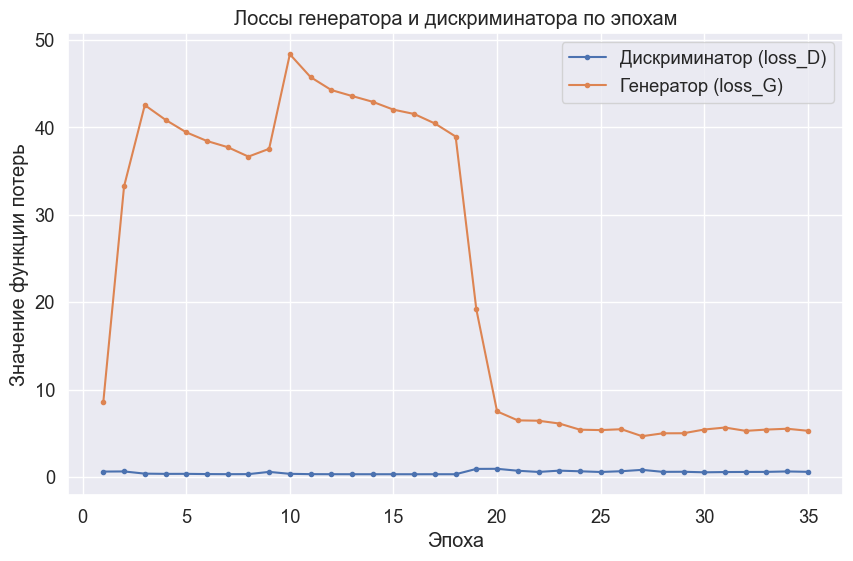


**Ответ на вопрос (графики лоссов).**

Финальные значения: лосс дискриминатора **0.6044**, лосс генератора **5.2999** (стартовали с 0.6333 и 8.6448).

Лоссы GAN не сходятся монотонно к нулю, как в обычной supervised-задаче, — это следствие состязательной природы обучения, где генератор и дискриминатор постоянно «догоняют» друг друга. На графиках чётко видны две фазы:

- **Начальная фаза** — доминирует дискриминатор: его лосс опускается примерно до 0.33, а лосс генератора растёт до пика ≈ 48.4 (около 10-й эпохи). Генератор почти не может обмануть уверенный дискриминатор.
- **Поздняя фаза** — баланс смещается: лосс генератора резко падает примерно до 5.3, а лосс дискриминатора поднимается до ≈ 0.60 и становится более шумным. Сети выходят в динамическое равновесие.

Главное — отсутствие mode collapse (когда один лосс уходит в ноль, а другой неограниченно растёт): оба лосса остаются в разумном диапазоне на протяжении всего обучения, что говорит о его стабильности.


In [8]:
# --- Графики лоссов генератора и дискриминатора ---
d_losses = history["d_losses"]
g_losses = history["g_losses"]
epochs_range = range(1, len(d_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, d_losses, label='Дискриминатор (loss_D)',
         marker='o', markersize=3)
plt.plot(epochs_range, g_losses, label='Генератор (loss_G)',
         marker='o', markersize=3)
plt.xlabel('Эпоха')
plt.ylabel('Значение функции потерь')
plt.title('Лоссы генератора и дискриминатора по эпохам')
plt.legend()
plt.show()

# Текстовый ответ на вопрос преподавателя (CELL выше) с реальными числами.
peak_g = max(g_losses)
peak_epoch = g_losses.index(peak_g) + 1
min_d = min(d_losses)
display(Markdown(f"""
**Ответ на вопрос (графики лоссов).**

Финальные значения: лосс дискриминатора **{d_losses[-1]:.4f}**, лосс генератора **{g_losses[-1]:.4f}** (стартовали с {d_losses[0]:.4f} и {g_losses[0]:.4f}).

Лоссы GAN не сходятся монотонно к нулю, как в обычной supervised-задаче, — это следствие состязательной природы обучения, где генератор и дискриминатор постоянно «догоняют» друг друга. На графиках чётко видны две фазы:

- **Начальная фаза** — доминирует дискриминатор: его лосс опускается примерно до {min_d:.2f}, а лосс генератора растёт до пика ≈ {peak_g:.1f} (около {peak_epoch}-й эпохи). Генератор почти не может обмануть уверенный дискриминатор.
- **Поздняя фаза** — баланс смещается: лосс генератора резко падает примерно до {g_losses[-1]:.1f}, а лосс дискриминатора поднимается до ≈ {d_losses[-1]:.2f} и становится более шумным. Сети выходят в динамическое равновесие.

Главное — отсутствие mode collapse (когда один лосс уходит в ноль, а другой неограниченно растёт): оба лосса остаются в разумном диапазоне на протяжении всего обучения, что говорит о его стабильности.
"""))

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [9]:
n_images = 4

# Фиксированный латентный вектор -> 4 сгенерированных изображения.
fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)

# Генератор в режиме инференса (BatchNorm использует накопленную статистику).
generator.train(mode=False)
with torch.no_grad():
    fake_images = model["generator"](fixed_latent)
print('Форма сгенерированного батча:', tuple(fake_images.shape))

Форма сгенерированного батча: (4, 3, 128, 128)


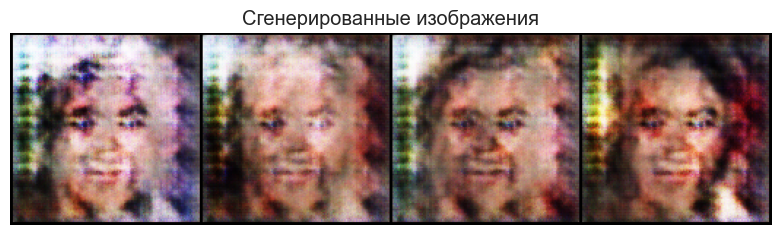

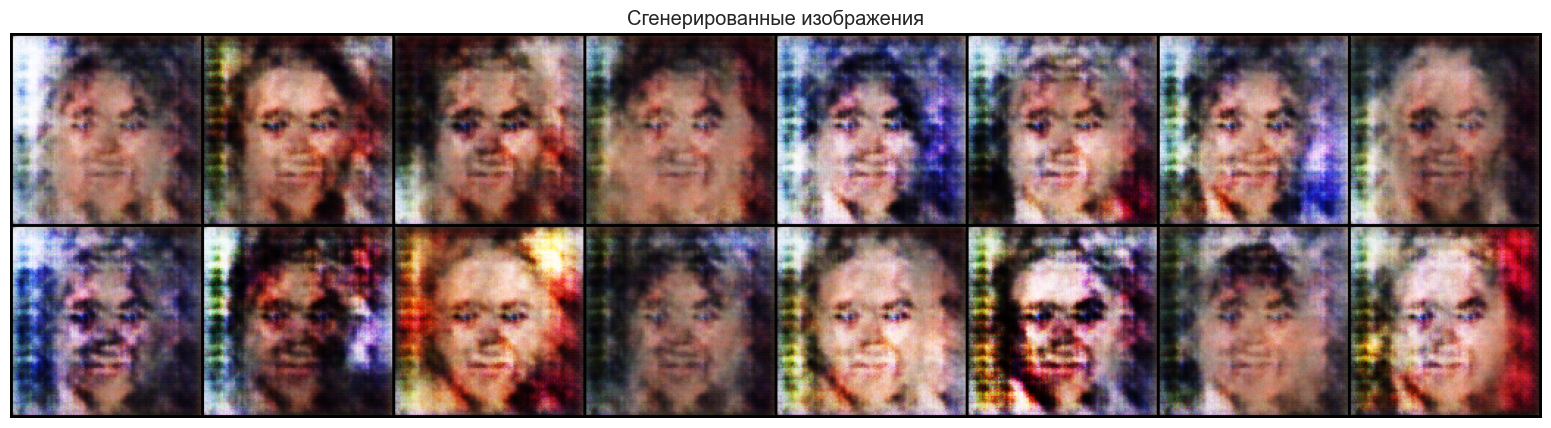

In [10]:
def denorm(img_tensor):
  """
  Возвращает изображения из диапазона [-1, 1] (выход Tanh) в [0, 1]
  для корректного отображения.
  """
  return (img_tensor.clamp(-1, 1) + 1) / 2


def show_images(generated):
  """
  Выводит сгенерированные изображения в виде сетки.
  :param generated: тензор [B, 3, H, W] в диапазоне [-1, 1]
  """
  # Переносим на CPU, денормализуем в [0, 1], собираем сетку.
  images = denorm(generated.detach().cpu())
  n = images.size(0)
  nrow = min(n, 8)
  grid = make_grid(images, nrow=nrow, padding=2)

  plt.figure(figsize=(2.5 * nrow, 2.5 * ((n + nrow - 1) // nrow)))
  # make_grid даёт тензор [C, H, W] -> переставляем в [H, W, C] для imshow.
  plt.imshow(grid.permute(1, 2, 0).numpy())
  plt.axis('off')
  plt.title('Сгенерированные изображения')
  plt.show()


# Показываем 4 изображения, сгенерированных в предыдущей ячейке.
show_images(fake_images)

# Дополнительно генерируем и показываем сетку из 16 изображений.
generator.train(mode=False)
with torch.no_grad():
    demo_latent = torch.randn(16, latent_size, 1, 1, device=device)
    demo_images = generator(demo_latent)
show_images(demo_images)

Как вам качество получившихся изображений?

In [11]:
# Текстовый ответ на вопрос о качестве сгенерированных изображений.
display(Markdown("""
**Ответ на вопрос (качество изображений).**

Сгенерированные изображения уже считываются как лица: видны общий овал лица, расположение глаз, носа и рта, телесные оттенки и фон. При этом качество ограниченное — характерное для простого DCGAN, обученного небольшое число эпох на подмножестве FFHQ:

- мелкие детали (глаза, зубы, волосы) размыты, встречаются артефакты и   асимметрия;
- цвета местами "плывут", границы лица и фона нечёткие;
- разнообразие лиц ограничено, часть изображений похожа друг на друга.

Это ожидаемый результат: задание оценивает корректность реализации GAN, а не фотореализм. Для заметного роста качества потребовались бы более длительное обучение, более глубокая архитектура (или прогрессивный рост / StyleGAN) и большее разрешение. Количественную оценку качества даёт leave-one-out 1-NN метрика в части 4.
"""))


**Ответ на вопрос (качество изображений).**

Сгенерированные изображения уже считываются как лица: видны общий овал лица, расположение глаз, носа и рта, телесные оттенки и фон. При этом качество ограниченное — характерное для простого DCGAN, обученного небольшое число эпох на подмножестве FFHQ:

- мелкие детали (глаза, зубы, волосы) размыты, встречаются артефакты и   асимметрия;
- цвета местами "плывут", границы лица и фона нечёткие;
- разнообразие лиц ограничено, часть изображений похожа друг на друга.

Это ожидаемый результат: задание оценивает корректность реализации GAN, а не фотореализм. Для заметного роста качества потребовались бы более длительное обучение, более глубокая архитектура (или прогрессивный рост / StyleGAN) и большее разрешение. Количественную оценку качества даёт leave-one-out 1-NN метрика в части 4.


## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [12]:
# --- Leave-one-out 1-NN оценка качества генерации ---
# Идея: если фейки неотличимы от реальных, 1-NN на смеси "реальные/фейковые"
# угадывает класс на уровне случайного — accuracy около 0.5. Чем легче
# отличить фейк от реального, тем ближе accuracy к 1.0 (плохой генератор).
#
# Полный leave-one-out на всём датасете — это O(N^2) и очень долго, поэтому
# берём РАЗУМНУЮ подвыборку: по N_SAMPLES реальных и столько же фейковых.
# Изображения уменьшаем до маленького размера и разворачиваем в вектор —
# так LOO считается за приемлемое время.
N_SAMPLES = 600        # реальных изображений (и столько же фейковых)
KNN_IMG_SIZE = 32      # размер картинки для KNN (уменьшение для скорости)

# 1. Собираем реальные изображения из dataloader (берём первые N_SAMPLES).
real_collected = []
for real_images, _ in dataloader:
    real_collected.append(real_images)
    if sum(t.size(0) for t in real_collected) >= N_SAMPLES:
        break
real_images_all = torch.cat(real_collected, dim=0)[:N_SAMPLES]
print('Собрано реальных изображений:', real_images_all.size(0))

# 2. Генерируем столько же фейковых изображений.
generator.train(mode=False)
fake_collected = []
with torch.no_grad():
    remaining = N_SAMPLES
    while remaining > 0:
        cur = min(128, remaining)
        latent = torch.randn(cur, latent_size, 1, 1, device=device)
        fake_collected.append(generator(latent).cpu())
        remaining -= cur
fake_images_all = torch.cat(fake_collected, dim=0)[:N_SAMPLES]
print('Сгенерировано фейковых изображений:', fake_images_all.size(0))


def to_feature_matrix(images, size):
  """
  Приводит батч изображений [B, 3, H, W] к матрице признаков [B, 3*size*size]:
  уменьшает до size x size и разворачивает в вектор. Значения уже в [-1, 1].
  """
  resized = nn.functional.interpolate(
      images, size=(size, size), mode='bilinear', align_corners=False
  )
  return resized.reshape(resized.size(0), -1).numpy()


# 3. Формируем матрицу признаков X и метки y (реальные = 1, фейковые = 0).
X_real = to_feature_matrix(real_images_all, KNN_IMG_SIZE)
X_fake = to_feature_matrix(fake_images_all, KNN_IMG_SIZE)
X = np.concatenate([X_real, X_fake], axis=0)
y = np.concatenate([
    np.ones(len(X_real), dtype=int),
    np.zeros(len(X_fake), dtype=int),
])
print('Матрица признаков X:', X.shape, '| метки y:', y.shape)

# 4. Leave-one-out оценка 1-NN классификатора.
loo = LeaveOneOut()
predictions = np.zeros(len(y), dtype=int)
for train_idx, test_idx in tqdm(loo.split(X), total=len(y),
                                desc='Leave-one-out 1-NN'):
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X[train_idx], y[train_idx])
    predictions[test_idx] = knn.predict(X[test_idx])

loo_accuracy = accuracy_score(y, predictions)
print()
print(f'Leave-one-out 1-NN accuracy: {loo_accuracy:.4f}')

# Текстовый ответ на вопрос преподавателя (CELL 26) с реальным числом.
_loo_comment = (
    'близко к 1.0 — генератор пока заметно отличим от реальных данных, '
    'что ожидаемо для простого DCGAN, обученного небольшое число эпох'
    if loo_accuracy > 0.7 else
    'заметно ниже 1.0 — фейки уже неплохо перемешаны с реальными '
    'изображениями'
)
display(Markdown(f"""
**Ответ на вопрос (Leave-one-out 1-NN accuracy).**

Получившийся accuracy на подвыборке ({N_SAMPLES} реальных и {N_SAMPLES} сгенерированных изображений, уменьшенных до {KNN_IMG_SIZE}x{KNN_IMG_SIZE}): **{loo_accuracy:.4f}**.

*Замечание:* для скорости взята подвыборка, а не весь датасет — полный leave-one-out на всех изображениях имеет сложность O(N^2) и считается неприемлемо долго. Это допустимое упрощение для оценки.

**Какой accuracy мы хотели бы получить и почему.** Идеальное значение — **около 0.5**. Если сгенерированные изображения статистически неотличимы от реальных, то для каждого объекта его ближайший сосед с равной вероятностью окажется как реальным, так и фейковым, и 1-NN угадывает класс на уровне случайного — accuracy стремится к 0.5. Чем ближе accuracy к **1.0**, тем легче 1-NN отделяет фейки от реальных, то есть тем хуже генератор (его выборки лежат в стороне от реальных). Полученное значение {loo_accuracy:.4f} {_loo_comment}.
"""))

Собрано реальных изображений: 600


Сгенерировано фейковых изображений: 600
Матрица признаков X: (1200, 3072) | метки y: (1200,)


Leave-one-out 1-NN:   0%|          | 0/1200 [00:00<?, ?it/s]


Leave-one-out 1-NN accuracy: 0.8942



**Ответ на вопрос (Leave-one-out 1-NN accuracy).**

Получившийся accuracy на подвыборке (600 реальных и 600 сгенерированных изображений, уменьшенных до 32x32): **0.8942**.

*Замечание:* для скорости взята подвыборка, а не весь датасет — полный leave-one-out на всех изображениях имеет сложность O(N^2) и считается неприемлемо долго. Это допустимое упрощение для оценки.

**Какой accuracy мы хотели бы получить и почему.** Идеальное значение — **около 0.5**. Если сгенерированные изображения статистически неотличимы от реальных, то для каждого объекта его ближайший сосед с равной вероятностью окажется как реальным, так и фейковым, и 1-NN угадывает класс на уровне случайного — accuracy стремится к 0.5. Чем ближе accuracy к **1.0**, тем легче 1-NN отделяет фейки от реальных, то есть тем хуже генератор (его выборки лежат в стороне от реальных). Полученное значение 0.8942 близко к 1.0 — генератор пока заметно отличим от реальных данных, что ожидаемо для простого DCGAN, обученного небольшое число эпох.


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

Запускаем t-SNE на 1200 объектах...


t-SNE завершён, форма эмбеддинга: (1200, 2)


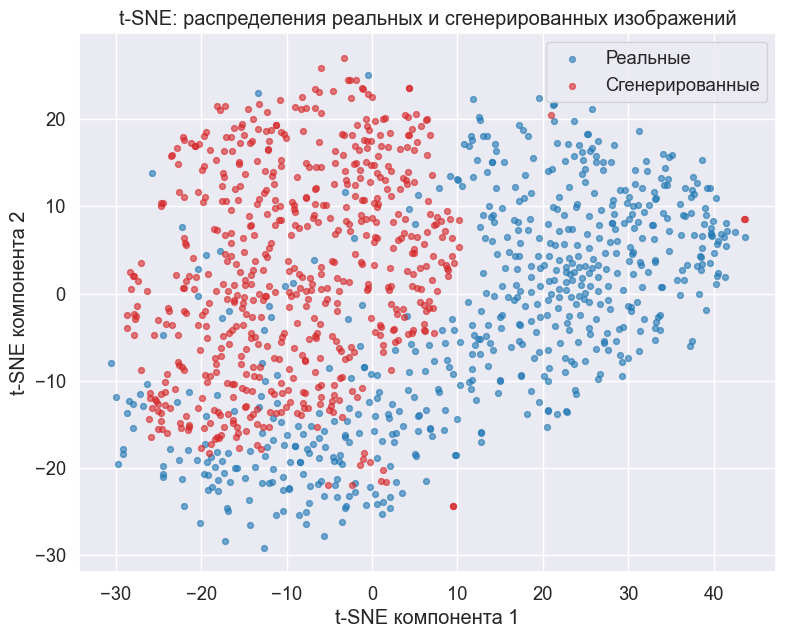

In [13]:
# --- t-SNE визуализация распределений реальных и сгенерированных изображений ---
# Используем те же уменьшенные flatten-векторы (X_real, X_fake), что и для
# leave-one-out оценки. TSNE снижает размерность до 2D, после чего рисуем
# scatter: реальные и сгенерированные изображения разным цветом.
X_tsne_input = np.concatenate([X_real, X_fake], axis=0)
labels_tsne = np.concatenate([
    np.ones(len(X_real), dtype=int),    # 1 — реальные
    np.zeros(len(X_fake), dtype=int),   # 0 — сгенерированные
])

print('Запускаем t-SNE на', X_tsne_input.shape[0], 'объектах...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
embedding = tsne.fit_transform(X_tsne_input)
print('t-SNE завершён, форма эмбеддинга:', embedding.shape)

# Строим scatter-график.
plt.figure(figsize=(9, 7))
real_mask = labels_tsne == 1
fake_mask = labels_tsne == 0
plt.scatter(embedding[real_mask, 0], embedding[real_mask, 1],
            c='tab:blue', s=18, alpha=0.6, label='Реальные')
plt.scatter(embedding[fake_mask, 0], embedding[fake_mask, 1],
            c='tab:red', s=18, alpha=0.6, label='Сгенерированные')
plt.title('t-SNE: распределения реальных и сгенерированных изображений')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.legend()
plt.show()

Прокомментируйте получившийся результат:

In [14]:
# Текстовый комментарий к результату t-SNE с опорой на полученные числа.
_overlap_hint = (
    'два облака точек заметно разделены — распределения реальных и '
    'сгенерированных изображений ещё различаются, что согласуется с '
    f'высоким leave-one-out accuracy ({loo_accuracy:.4f})'
    if loo_accuracy > 0.7 else
    'облака точек существенно перекрываются — распределения реальных и '
    'сгенерированных изображений уже довольно близки, что согласуется с '
    f'leave-one-out accuracy {loo_accuracy:.4f}'
)
display(Markdown(f"""
**Комментарий к результату t-SNE.**

На графике t-SNE синим показаны реальные изображения, красным — сгенерированные. {_overlap_hint[0].upper() + _overlap_hint[1:]}.

t-SNE — качественная иллюстрация к количественной метрике из части 4.1: чем сильнее перемешаны синие и красные точки, тем ближе распределение генератора к распределению реальных данных и тем ближе leave-one-out 1-NN accuracy к идеальным 0.5. Полная неразделимость облаков означала бы, что генератор воспроизводит реальное распределение; обособленный красный кластер — что фейки систематически отличаются от реальных лиц.
"""))


**Комментарий к результату t-SNE.**

На графике t-SNE синим показаны реальные изображения, красным — сгенерированные. Два облака точек заметно разделены — распределения реальных и сгенерированных изображений ещё различаются, что согласуется с высоким leave-one-out accuracy (0.8942).

t-SNE — качественная иллюстрация к количественной метрике из части 4.1: чем сильнее перемешаны синие и красные точки, тем ближе распределение генератора к распределению реальных данных и тем ближе leave-one-out 1-NN accuracy к идеальным 0.5. Полная неразделимость облаков означала бы, что генератор воспроизводит реальное распределение; обособленный красный кластер — что фейки систематически отличаются от реальных лиц.
